In [1]:
#@title Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Set device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Part 1: Load/Analyze Data

##What is your dataset? Please describe your dataset and where you got it

My dataset is the CIFAR-10 image classification dataset.

##Load your dataset / Implement your dataloader

In [2]:
# TODO - load your dataset and set up your dataloader
# If applicable, please include your data with your final submission
# along with instructions for how to load it

# Note to self.
# So here, i have 60'000 images that each have a size of 32x32 pixels that have colors.
# But before i use the data to train my model, I have to change the rgb values of the pixel to be from [-1, 1].
# First i should make the rgb values range from [0,1] and then i should make it range from [-1,1].
# Remember, the reason why i am doing this process is that it is easier to train the model on this kind of data.

# The transformer to use
transform = transforms.Compose([
    # Here i map the values of each rgb vlaue of a pixel to [0,1]
    transforms.ToTensor(),
    # and here i normalize those rgb values of a pixel to be inside [-1,1]
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# I will import the dataset here and apply the transformer here.
train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.CIFAR10(root="./data", train=False, transform=transform, download=True)
training, validation = torch.utils.data.random_split(train_dataset, [40000, 10000])

# now i have to load the dataset
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 20

train_loader = DataLoader(training, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
validation_loader = DataLoader(validation, batch_size=BATCH_SIZE, shuffle=True)

# TODO - if not already done, please make a train/val/test split of your dataset

100%|██████████| 170M/170M [00:03<00:00, 48.8MB/s]


##Dataset Analyis Statistics

tensor(-1.) tensor(0.8667)
tensor(-1.) tensor(0.8039)
tensor(-0.9922) tensor(1.)
tensor(-0.9529) tensor(1.)
tensor(-0.7961) tensor(0.8902)


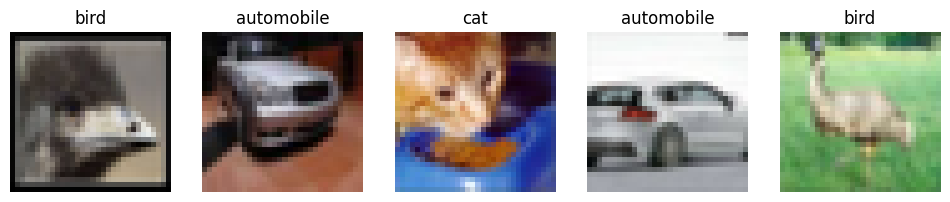

In [3]:
# TODO - code for collecting statistics from your dataset / plots and analysis

# Here i'll mmake 5 images from my training data set
data_iter = iter(train_loader)
images, labels = next(data_iter)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

num_images = 5
fig, axes = plt.subplots(1, num_images, figsize=(12, 3))

for i in range(num_images):
    img = images[i].squeeze().numpy()
    label = class_names[labels[i].item()]
    print(images[i].min(), images[i].max())

    # Here i have to swap the axes because the dataloader gives me the image in a non-suitable order.
    # The imshow() method requires an image to be Height, Width and Channel. But the dataloader gave
    # me Channel, Height and Width.
    # So i basically have to swap Channel with Width. Which gives me: (w,h,c)
    # and then swap Width with Height. And that gives me: (h, w, c)
    img = img.swapaxes(0,2)
    img = img.swapaxes(0,1)

    # Just for better visualization, i undo the normalization so the image can look a lot more better.
    img = img * 0.5 + 0.5

    axes[i].imshow(img)
    axes[i].set_title(label)
    axes[i].axis("off")

plt.show()

TODO - Provide the analysis and statistics of your data

● Description of the data set
The CIFAR-10 is a data set with 60'000 images and 10 classes. The images are 32x32 size with rgb values. Each image
is labeled with a label from 0-9 that corresponds to a class. The 10 classes are: "airplane", "automobile", "bird", "cat", "deer",
"dog", "frog", "horse", "ship" and "truck".

● Format of the inputs and outputs
The input would be a 32x32x3 and a label that will be 0-9 will be the output.

● Number of examples in the train/val/test splits
It has 50'000 training images and 10'000 test images.

● A visualization of at least 5 examples from your dataset
Please see the 5 images above

● Summary statistics
Each image is 32x32x3 where it is 32 pixels tall and 32 pixel wide and has 3 rgb channels.

● Training/Test/Val split
The CIFAR-10 dataset already comes split with 50'000 images as training and 10'000 images for testing. I have split the training data into 40'000 training data and 10'000 validation data.


# Part 2: Literature Review

TODO - Follow instructions in the assignment for your literature review

1. CIFAR-10 Image Classification Based on Convolutional Neural Network
by:
Xiyun Lv
College of Electrical & Information Engineering, Southwest Minzu University, Chengdu 610041, China
Email: 1045106108@qq.com

This paper states that they used the CIFAR-10 dataset to improve the ResNet model's accuracy using SGD up to 90.85%
whereas a typical CNN model (the one i am about to make) has on average around 70-85% accuracy. The paper also talks
about augmenting the CIFAR-10 images to increase the dataset size for better training and testing. They claim that
flipping the images horizontally, up, and down, and also whitening the image, darkening it, changing the contrast,
randomwly cropping it form a new image and thus increasing the amount of data they can use.

2. Batch Normalization in Convolutional Neural Networks — A comparative study with CIFAR-10 data
by:
V. Thakkar, S. Tewary and C. Chakraborty, "Batch Normalization in Convolutional Neural Networks — A comparative study with CIFAR-10 data," 2018 Fifth International Conference on Emerging Applications of Information Technology (EAIT), Kolkata, India, 2018, pp. 1-5, doi: 10.1109/EAIT.2018.8470438. keywords: {Training;Machine learning;Convolutional neural networks;Data models;Atmospheric modeling;Task analysis;Analytical models;Activation function;Batch normalization;Convolutional Neural Networks;Deep Learning;and Image Analysis.},

This paper talks about the importance of batch-normalization for convolutional networks by performing tests on different
networks such as CNN, VGG, Inception and Residual Network with different activation functions.
They state that not only batch normalization is importatn for training convolutional networks, but it is essential.
They performed all the tests on the CIFAR-10 dataset and showed their accuracies.



# Part 3: Implement networks in PyTorch

Note of warning here: Depending on how easily you can allocate GPU resources, you may want to make your network much shallower so that you can train it more easily
Aim to have one gradient update take no more than a few seconds
May also want to reduce the number of training steps if training is too slow

In [8]:
# TODO - implement your PyTorch Module
# I will be making a CNN model.

class CNN(nn.Module):
    def __init__(self, kernel_size=16):
        super().__init__()

        # Note to self.
        # First i have to do convolution layer.
        # Second I have to do an activation layer.
        # Third I have to do a pool layer.

        # Im going to make this conv layer's filter a 4x4 window with a stride of 2.
        # This should produce KERNEL_SIZE channels that are all 15x15.
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=kernel_size, kernel_size=4, stride=2)

        # The second conv layer will have a kernel size of 3x3 and an output channel size of 32.
        # This should produce 32 channels that are all 13x13
        self.conv2 = nn.Conv2d(in_channels=kernel_size, out_channels=32, kernel_size=3, stride=1)

        # Now i'll make the pooling layer.
        # This should make an output of 32 output channels that are all 6x6 iamges.
        self.pool1 = nn.MaxPool2d(2, 2)

        # Now i have to implement the fc layer
        self.fc1 = nn.Linear(32 * 6 * 6, 128)

        # Im going to make another fc layer so it can map the produced 128 values to the 10 class values.
        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    # Now i have to make the forward function where all the magicc happens
    def forward(self, x):
        # First pass the input through the first conv layer
        # Output should be 15x15 mappings with 16 channels.
        x = self.conv1(x)

        # Now pass the output through the activation layer
        x = self.relu(x)

        # Now pass the output through the second conv layer
        # Output should be 13x13 mappings with 32 channels
        x = self.conv2(x)

        # pass the output through the activation layer again
        x = self.relu(x)

        # Now pass the output throguh the pooling layer
        # Output should be 6x6 mappings with 32 channels
        x = self.pool1(x)

        # Need to flatten the entire output into one single dimensional vector before passing into the fc layer.
        x = torch.flatten(x, 1)

        # Now pass through the fully connected layer 1
        # Output: One dimensional 128 length
        x = self.fc1(x)

        # Pass through the final fc layer
        # Output: One dimensional, length 10
        x = self.fc2(x)

        return x

In [5]:
# TODO - implement your training loop

# Initialize Model
model = CNN().to(device)

# Define a Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

training_accuracy = []
validation_accuracy = []

# Training Loop
print("Training model...")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Reset the optimizer's gradients to avoid accumulation
        optimizer.zero_grad()

        # Perform a forward pass to get model predictions
        pred = model.forward(images)

        # Compute the loss using the criterion
        loss = criterion(pred, labels)

        # Backpropagate the loss to compute gradients
        loss.backward()

        # Update model parameters using the optimizer
        optimizer.step()

        # Accumulate the loss for tracking the epoch's loss
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss/len(train_loader):.4f}")

    # Collecting training data
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    training_accuracy.append(accuracy)
    print(f"Train Accuracy: {accuracy:.4f}")


    # Collecting validation data
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in validation_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    validation_accuracy.append(accuracy)
    print(f"Validation Accuracy: {accuracy:.4f}")
    print("")



Training model...
Epoch 1/20, Loss: 1.4956
Train Accuracy: 0.5750
Validation Accuracy: 0.5557

Epoch 2/20, Loss: 1.1893
Train Accuracy: 0.6217
Validation Accuracy: 0.5916

Epoch 3/20, Loss: 1.0908
Train Accuracy: 0.6394
Validation Accuracy: 0.6024

Epoch 4/20, Loss: 1.0328
Train Accuracy: 0.6682
Validation Accuracy: 0.6195

Epoch 5/20, Loss: 0.9911
Train Accuracy: 0.6764
Validation Accuracy: 0.6192

Epoch 6/20, Loss: 0.9542
Train Accuracy: 0.6847
Validation Accuracy: 0.6188

Epoch 7/20, Loss: 0.9249
Train Accuracy: 0.7030
Validation Accuracy: 0.6338

Epoch 8/20, Loss: 0.9017
Train Accuracy: 0.7089
Validation Accuracy: 0.6329

Epoch 9/20, Loss: 0.8756
Train Accuracy: 0.7159
Validation Accuracy: 0.6362

Epoch 10/20, Loss: 0.8577
Train Accuracy: 0.7106
Validation Accuracy: 0.6234

Epoch 11/20, Loss: 0.8416
Train Accuracy: 0.7316
Validation Accuracy: 0.6344

Epoch 12/20, Loss: 0.8261
Train Accuracy: 0.7393
Validation Accuracy: 0.6371

Epoch 13/20, Loss: 0.8126
Train Accuracy: 0.7283
Valida

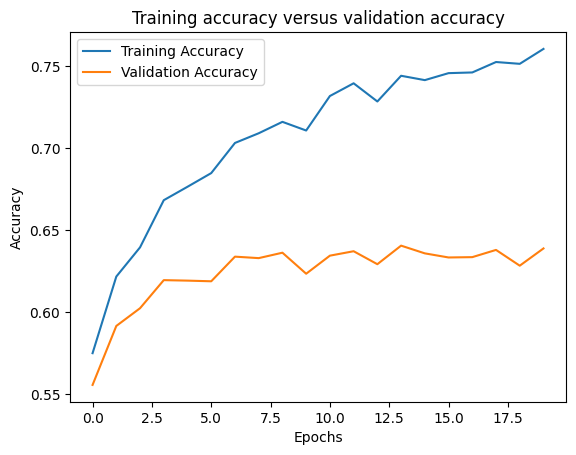

In [6]:
# Plotting
length = [i for i in range(EPOCHS)]
plt.title('Training accuracy versus validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.plot(length, training_accuracy, label="Training Accuracy")
plt.plot(length, validation_accuracy, label="Validation Accuracy")
plt.legend()
plt.show()


Hint: look at earlier homeworks / resuse code from those to help you here

# Part 4: Run Hyperparameter Experiments

In [11]:
# TODO - perform hyperparameter grid searches and plot accuracies

# Now i have to define a hyperparameter grid
param_grid = {
    'batch_size': [128, 256],
    'epochs': [5, 10],
    'learning_rate': [0.001, 0.005],
    'kernels': [8, 32]
}

best_tr_accuracy = 0
best_val_accuracy = 0
best_batch_size = None
best_epochs = None
best_learning_rate = None

best_training_accuracies = []
best_val_accuracies = []

for BATCH_SIZE in param_grid['batch_size']:
  for epochs in param_grid['epochs']:
    for learning_rate in param_grid['learning_rate']:
      for kernel in param_grid['kernels']:

        train_loader = DataLoader(training, batch_size=BATCH_SIZE, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)
        validation_loader = DataLoader(validation, batch_size=BATCH_SIZE, shuffle=True)

        model = CNN(kernel_size=kernel).to(device)

        # Define a Loss function and Optimizer
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

        training_accuracy = []
        validation_accuracy = []

        # Training Loop
        print("Training model...")
        for epoch in range(epochs):
            model.train()
            epoch_loss = 0
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)

                # Reset the optimizer's gradients to avoid accumulation
                optimizer.zero_grad()

                # Perform a forward pass to get model predictions
                pred = model.forward(images)

                # Compute the loss using the criterion
                loss = criterion(pred, labels)

                # Backpropagate the loss to compute gradients
                loss.backward()

                # Update model parameters using the optimizer
                optimizer.step()

                # Accumulate the loss for tracking the epoch's loss
                epoch_loss += loss.item()

            print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")

            # Collecting training data
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for images, labels in train_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()
            tr_accuracy = correct / total
            training_accuracy.append(tr_accuracy)
            print(f"Train Accuracy: {tr_accuracy:.4f}")


            # Collecting validation data
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for images, labels in validation_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    _, predicted = torch.max(outputs, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()
            val_accuracy = correct / total
            validation_accuracy.append(val_accuracy)
            print(f"Validation Accuracy: {val_accuracy:.4f}")
            print("")

        if val_accuracy > best_val_accuracy:
          best_tr_accuracy = tr_accuracy
          best_val_accuracy = val_accuracy
          best_batch_size = BATCH_SIZE
          best_epochs = epochs
          best_learning_rate = learning_rate
          best_training_accuracies = training_accuracy.copy()
          best_val_accuracies = validation_accuracy.copy()
          best_kernel_size = kernel

# Plotting
length = [i for i in range(best_epochs)]
plt.title('Training accuracy versus validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.plot(length, best_training_accuracies, label="Training Accuracy")
plt.plot(length, best_val_accuracies, label="Validation Accuracy")
plt.legend()
plt.show()

print(f"best_trainig_accuracy: {best_tr_accuracy}, best_val_accuracy: {best_val_accuracy}, best_batch_size: {best_batch_size}, best_epochs: {best_epochs}, best_learning_rate: {best_learning_rate}, best_kernel_size: {best_kernel_size}")


Training model...
Epoch 1/5, Loss: 1.6252
Train Accuracy: 0.5000
Validation Accuracy: 0.4853

Epoch 2/5, Loss: 1.3386
Train Accuracy: 0.5694
Validation Accuracy: 0.5500

Epoch 3/5, Loss: 1.2174
Train Accuracy: 0.6076
Validation Accuracy: 0.5798

Epoch 4/5, Loss: 1.1344
Train Accuracy: 0.6329
Validation Accuracy: 0.6005

Epoch 5/5, Loss: 1.0890
Train Accuracy: 0.6486
Validation Accuracy: 0.6058

Training model...
Epoch 1/5, Loss: 1.5188
Train Accuracy: 0.5491
Validation Accuracy: 0.5297

Epoch 2/5, Loss: 1.1994
Train Accuracy: 0.6128
Validation Accuracy: 0.5854

Epoch 3/5, Loss: 1.0899
Train Accuracy: 0.6423
Validation Accuracy: 0.6041

Epoch 4/5, Loss: 1.0243
Train Accuracy: 0.6717
Validation Accuracy: 0.6258

Epoch 5/5, Loss: 0.9758
Train Accuracy: 0.6929
Validation Accuracy: 0.6414

Training model...
Epoch 1/5, Loss: 1.4768
Train Accuracy: 0.5550
Validation Accuracy: 0.5328

Epoch 2/5, Loss: 1.1996
Train Accuracy: 0.5997
Validation Accuracy: 0.5623

Epoch 3/5, Loss: 1.1135
Train Accu

KeyboardInterrupt: 

In [ ]:
# TODO - perform other experiments and plot accuracies
# Sadly i couldn't do it, i realize my expirement was over-ambitious :( it was too hard


In [ ]:
# TODO - calculate the final test accuracy
best_model = CNN(kernel_size=best_kernel_size).to(device)

# Define a Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(best_model.parameters(), lr=best_learning_rate)

# Loading test data
train_loader = DataLoader(training, batch_size=best_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=best_batch_size)

# Training Loop
print("Training model...")
for epoch in range(best_epochs):
    best_model.train()
    epoch_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Reset the optimizer's gradients to avoid accumulation
        optimizer.zero_grad()

        # Perform a forward pass to get model predictions
        pred = best_model.forward(images)

        # Compute the loss using the criterion
        loss = criterion(pred, labels)

        # Backpropagate the loss to compute gradients
        loss.backward()

        # Update model parameters using the optimizer
        optimizer.step()

        # Accumulate the loss for tracking the epoch's loss
        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{best_epochs}, Loss: {epoch_loss/len(train_loader):.4f}")

# Collecting training data
best_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
test_accuracy = correct / total
print(f"Test Accuracy: {test_accuracy:.4f}")


Training model...
Epoch 1/10, Loss: 1.5315
Epoch 2/10, Loss: 1.2028
Epoch 3/10, Loss: 1.0892
Epoch 4/10, Loss: 1.0205
Epoch 5/10, Loss: 0.9757
Epoch 6/10, Loss: 0.9365


TODO - Explain your experiments above. See assignment doc for more details.

I am going to attempt to augment the dataset by increasing the number of images inside the training and test data. I am taking inspiration from the literature review where it was mentioned that the researchers needed more dataset than what they already had in the CIFAR-10, so they started augmenting the data they already had by rotating the images 90 degrees, flipping them horizontally, up and down, and changing the contrast levels of the images. I am going to try changing the contrast levels of random images and adding them to the training and test data to increase the number of training and test data.

Heres my overall plan:
1. Load the train and test dataset. Split the train data into train and validation set.
2. Pick a random image from the train dataset and increase or decrease the contrast levels of the RGB values by a random amount.
3. Create a new image from the image with the new contrast levels.
4. Add it back to its corresponding data set.
5. Repeat for all 3 training, validation and test dataset.
6. Do step 5 until training dataset is 50000 images, validation set is 10000 images, and test set is 20000 images. This means the total Dataset should have 80000 images, compared to the 60000 original images :).
7. Run the hyperparameter grid and plot.